# Linear Regression

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

## Problem Statement:
Suppose you are the CEO of a restaurant franchise and are considering new cities for opening a new outlet.
- You would like to expand your business to cities that may give your restaurant higher profits.
- The chain already had certain restaurants in various cities and you have data for profits and population from the cities.
- You also have data on cities that are candidates for a new restaurant.
- For these cities, you have the city population.

Use the data to help you identify which cities may potentially give you business higher profit?

## Dataset

In [31]:
def load_data(path):
    data = np.loadtxt(path,delimiter=',')
    X = data[:,0]
    y = data[:,1]

    return X,y

- x_train is population of cities
- y_train is profit of a restaurant in that city.

both x_train and y_train are numpy arrays

In [32]:
path = r"C:\Machine Learning\Coursera\Supervised ML (Regression and Classification)\02_Regression_Multiple_Variable\ex1data1.txt"

x_train, y_train = load_data(path)

In [33]:
print("Type of x_train:", type(x_train))
print("First five elements of x_train:\n", x_train[:5])
# 6.1101 means 6.1101 * 10000 = 61,101 population

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train:
 [6.1101 5.5277 8.5186 7.0032 5.8598]


In [34]:
print("Type of y_train:", type(y_train))
print("First five elements of y_train:\n", y_train[:5])
# 17.592 means 17.592 * $10,000 = $175,920

Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train:
 [17.592   9.1302 13.662  11.854   6.8233]


### Check the dimensions of your variables

In [35]:
print("The shape of x_train is:", x_train.shape)
print("The shape of y_train is:", y_train.shape)
print("Number of training examples(m):", len(x_train))

The shape of x_train is: (97,)
The shape of y_train is: (97,)
Number of training examples(m): 97


### Visualize Data
- it is often useful to understand the data by visualizing it.
- for this dataset, we can use a scatter plot as it has only two properties.
- when we have more than two properties, we will still use the scatter plot for each pair of properties.

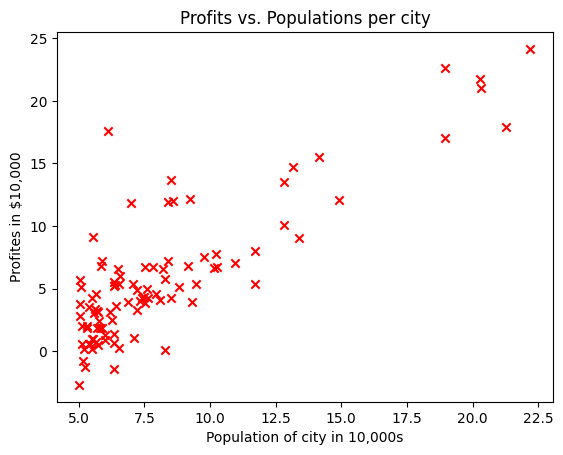

In [36]:
plt.scatter(x_train,y_train, marker='x',color='r')

plt.title("Profits vs. Populations per city")
plt.ylabel("Profites in $10,000")
plt.xlabel("Population of city in 10,000s")
plt.show()

## Compute Cost

In [37]:
def compute_cost(x,y,w,b):
    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i])**2

    return cost/(2*m)

In [38]:
initial_w = 2
initial_b = 1

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w: {cost:.3f}')

<class 'numpy.float64'>
Cost at initial w: 75.203


## Compute Gradient

In [39]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * (x[i])
        dj_db += (f_wb - y[i])

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

In [40]:
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -65.32884974555672 -5.83913505154639


### Batch Gradient Descent

In [41]:
def gradient_descent(x,y,w_in,b_in,cost_function,gradient_function,alpha,num_iters):
    m = x.shape[0]
    j_history = []
    w_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            cost = cost_function(x,y,w,b)
            j_history.append(cost)

        if i % math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration: {i:4}, cost: {float(j_history[-1]):8.2f}")

    return w,b,j_history,w_history

In [42]:
initial_w = 0.
initial_b = 0.

iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(x_train,y_train,initial_w,initial_b,compute_cost,compute_gradient,alpha,iterations)

print("w,b found by the gradient descent:", w,b)

Iteration:    0, cost:     6.74
Iteration:  150, cost:     5.31
Iteration:  300, cost:     4.96
Iteration:  450, cost:     4.76
Iteration:  600, cost:     4.64
Iteration:  750, cost:     4.57
Iteration:  900, cost:     4.53
Iteration: 1050, cost:     4.51
Iteration: 1200, cost:     4.50
Iteration: 1350, cost:     4.49
w,b found by the gradient descent: 1.166362350335582 -3.63029143940436


#### Predictions

In [43]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

Text(0.5, 0, 'Population of city in 10,000s')

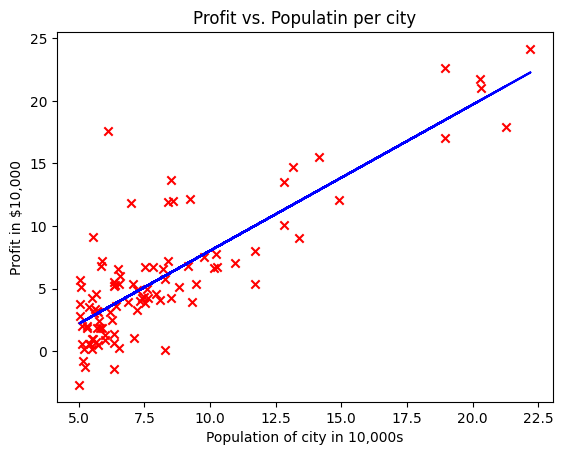

In [45]:
# Plot
plt.plot(x_train,predicted,color='b')

plt.scatter(x_train,y_train,marker='x',color='r')

plt.title("Profit vs. Populatin per city")
plt.ylabel("Profit in $10,000")
plt.xlabel("Population of city in 10,000s")

In [54]:
predict1 = 3.5 * w + b
print("For Population = 35,000, we predict a porfit of $%.2f" % (predict1*10000))
# %.2f will help to print exact to decimal places

predict2 = 7.0 * w + b
print("For Population = 70,000, we predict a profit of $%.2f" % (predict2*10000))

For Population = 35,000, we predict a porfit of $4519.77
For Population = 70,000, we predict a profit of $45342.45
